In [ ]:
# =============================================================================
# FULL DEBUG CELL — reproduces run_calibration.main()'s data pipeline exactly,
# then reproduces calibration.residuals() step by step with no try/except,
# so the real (currently swallowed) exception surfaces with a traceback.
# =============================================================================
import numpy as np
import pandas as pd
from src import config, calibration, model
from scripts.run_calibration import restrict_date_range
from src.data.data import contact_matrix, data
from src.data import historical_population  # adjust path if needed

# --- 0. MATCH THESE TO YOUR ACTUAL CLI INVOCATION ---------------------------
START = "1954-01-01"          # --start
END = "1960-01-01"            # --end
BURN_IN_YEARS = 20.0          # --burn-in-years
FIXED_REPORTING_RATE = None   # --reporting-rate (None -> config default)

# --- [1/5] processed case series --------------------------------------------
data.build_texas_measles_series()

# --- [2/5] contact matrix ----------------------------------------------------
contact_matrix.build_processed_contact_matrix()
contact_matrix_df = contact_matrix.load_processed_contact_matrix()
contact_matrix_array = contact_matrix_df.to_numpy()
print("contact_matrix shape:", contact_matrix_array.shape)
print("contact_matrix any NaN/inf:", np.any(~np.isfinite(contact_matrix_array)))

# --- [3/5] restrict window ----------------------------------------------------
full_series = data.load_processed_series()
start = START
end = END
windowed_series = restrict_date_range(full_series, start, end)
observed_times = data.series_to_elapsed_years(windowed_series)
observed_case_counts = windowed_series["case_count"].to_numpy()
print(f"{len(windowed_series)} weekly observations in window.")

window_start_year = pd.Timestamp(start).year

# --- observed-data sanity checks, BEFORE the model is touched at all --------
observed_times_arr = np.asarray(observed_times, dtype=float)
observed_counts_arr = np.asarray(observed_case_counts, dtype=float)

print("\n--- observed data shape/monotonicity checks ---")
print("dtype of raw case_count column:", windowed_series["case_count"].dtype)
print("observed_times shape:", observed_times_arr.shape)
print("observed_case_counts shape:", observed_counts_arr.shape)
diffs = np.diff(observed_times_arr)
print("strictly increasing?", np.all(diffs > 0))
if not np.all(diffs > 0):
    bad = np.where(diffs <= 0)[0]
    print(f"  {len(bad)} non-increasing gaps, first few indices: {bad[:10]}")
    print("  offending times:", observed_times_arr[bad[:5]], "->", observed_times_arr[bad[:5] + 1])
print("any duplicate period_start?", windowed_series["period_start"].duplicated().sum())
print("any NaN/inf in times?", np.any(~np.isfinite(observed_times_arr)))
print("any NaN/inf in counts?", np.any(~np.isfinite(observed_counts_arr)))
print("any negative counts?", np.any(observed_counts_arr < 0))

# --- vital rates --------------------------------------------------------------
birth_rate_fn, death_rate_fn = historical_population.build_vital_rate_functions()
fit_window_start_year = pd.Timestamp(start).year
birth_rate_of_t = lambda t: birth_rate_fn(fit_window_start_year + t)
death_rate_of_t = lambda t: death_rate_fn(fit_window_start_year + t)

# --- fold_burn_in logic, exactly as main() computes it -----------------------
initial_conditions = None
fold_burn_in = False
ic = config.INITIAL_CONDITIONS
print("\nconfig.INITIAL_CONDITIONS S0/I0/R0 are None?",
      [ic[k] is None for k in ("S0", "I0", "R0")])

if any(ic[k] is None for k in ("S0", "I0", "R0")):
    if BURN_IN_YEARS and BURN_IN_YEARS > 0:
        fold_burn_in = True
        print(f"fold_burn_in=True: burn-in ({BURN_IN_YEARS:.1f}yr before "
              f"{window_start_year}) will be re-derived per candidate.")
    else:
        target_population = historical_population.population_for_year(window_start_year)
        initial_conditions = historical_population.initial_conditions_for_population(target_population)
else:
    initial_conditions = ic

fit_start_year = window_start_year if fold_burn_in else None
burn_in_years = BURN_IN_YEARS if fold_burn_in else 0.0

# =============================================================================
# DEBUG PROPER — same sequence residuals() runs internally, minus the
# swallowing try/except.
# =============================================================================
fixed_gamma = calibration._resolve_fixed_gamma(None)
fixed_sigma = calibration._resolve_fixed_sigma(None)
fixed_mwr   = calibration._resolve_fixed_maternal_waning_rate(None)
fixed_reporting_rate = calibration._resolve_fixed_reporting_rate(FIXED_REPORTING_RATE)

print("\nfixed_gamma:", fixed_gamma)
print("fixed_sigma:", fixed_sigma)
print("fixed_maternal_waning_rate:", fixed_mwr)
print("fixed_reporting_rate:", fixed_reporting_rate)

beta_0, beta_1, phi = calibration.default_initial_guess()

params = calibration.build_full_parameters(
    beta_0, beta_1, phi, fixed_gamma,
    fixed_birth_rate=birth_rate_of_t,
    fixed_death_rate=death_rate_of_t,
    contact_matrix=contact_matrix_array,
    fixed_sigma=fixed_sigma,
    fixed_maternal_waning_rate=fixed_mwr,
)

if fold_burn_in:
    print("\n--- building burn-in IC (this is the expensive part) ---")
    candidate_ic = historical_population.initial_conditions_with_burn_in(
        fit_start_year=fit_start_year,
        burn_in_years=burn_in_years,
        contact_matrix_array=contact_matrix_array,
        burn_in_beta_0=beta_0,
        burn_in_beta_1=beta_1,
        burn_in_phi=phi,
        burn_in_gamma=fixed_gamma,
        burn_in_sigma=fixed_sigma,
        burn_in_maternal_waning_rate=fixed_mwr,
    )
else:
    candidate_ic = initial_conditions

for k in ("M0", "S0", "E0", "I0", "R0"):
    arr = candidate_ic[k]
    print(f"{k}: min={arr.min():.4g} max={arr.max():.4g} "
          f"any_nan={np.any(np.isnan(arr))} any_neg={np.any(arr < 0)}")

# --- the actual call that's failing inside residuals() — no try/except -----
print("\n--- calling weekly_modeled_incidence directly (uncaught) ---")
times_out, modeled_true, per_age = calibration.weekly_modeled_incidence(
    params, candidate_ic, observed_times_arr
)
print("times_out shape:", times_out.shape)
print("modeled_true shape:", modeled_true.shape)
print("observed[1:] shape:", observed_counts_arr[1:].shape)

modeled_reported = fixed_reporting_rate * modeled_true
r = calibration._poisson_deviance_residual(modeled_reported, observed_counts_arr[1:])
print("residual shape:", r.shape, " finite:", np.all(np.isfinite(r)))
print("residual sample:", r[:10])

contact_matrix shape: (6, 6)
contact_matrix any NaN/inf: False
313 weekly observations in window.

--- observed data shape/monotonicity checks ---
dtype of raw case_count column: float64
observed_times shape: (313,)
observed_case_counts shape: (313,)
strictly increasing? True
any duplicate period_start? 0
any NaN/inf in times? False
any NaN/inf in counts? False
any negative counts? False

config.INITIAL_CONDITIONS S0/I0/R0 are None? [True, True, True]
fold_burn_in=True: burn-in (20.0yr before 1954) will be re-derived per candidate.

fixed_gamma: 45.65625
fixed_sigma: 33.20454545454545
fixed_maternal_waning_rate: 1.6
fixed_reporting_rate: 0.15685714285714286

--- building burn-in IC (this is the expensive part) ---
M0: min=1002 max=7.693e+04 any_nan=False any_neg=False
S0: min=4.6e+04 max=2.38e+05 any_nan=False any_neg=False
E0: min=735.4 max=1691 any_nan=False any_neg=False
I0: min=442.1 max=1009 any_nan=False any_neg=False
R0: min=2.16e+04 max=7.227e+06 any_nan=False any_neg=False

--

In [2]:
test_points = {
    "start3_beta1_0.92": (619.508, 0.922419, 2.108654),
    "start4_beta1_0.98": (682.385, 0.979037, 1.05882),
    "start6_beta1_0.58": (601.477, 0.583899, 5.873794),
}

for label, (b0, b1, ph) in test_points.items():
    print(f"\n=== {label}: beta_0={b0}, beta_1={b1}, phi={ph} ===")
    params_t = calibration.build_full_parameters(
        b0, b1, ph, fixed_gamma,
        fixed_birth_rate=birth_rate_of_t,
        fixed_death_rate=death_rate_of_t,
        contact_matrix=contact_matrix_array,
        fixed_sigma=fixed_sigma,
        fixed_maternal_waning_rate=fixed_mwr,
    )
    try:
        ic_t = historical_population.initial_conditions_with_burn_in(
            fit_start_year=fit_start_year,
            burn_in_years=burn_in_years,
            contact_matrix_array=contact_matrix_array,
            burn_in_beta_0=b0, burn_in_beta_1=b1, burn_in_phi=ph,
            burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
            burn_in_maternal_waning_rate=fixed_mwr,
        )
        for k in ("M0", "S0", "E0", "I0", "R0"):
            arr = ic_t[k]
            print(f"  {k}: min={arr.min():.4g} max={arr.max():.4g} neg={np.any(arr<0)}")
        times_t, modeled_t, _ = calibration.weekly_modeled_incidence(params_t, ic_t, observed_times_arr)
        print("  succeeded, modeled_true[:5] =", modeled_t[:5])
    except Exception as e:
        import traceback
        print("  FAILED:")
        traceback.print_exc()


=== start3_beta1_0.92: beta_0=619.508, beta_1=0.922419, phi=2.108654 ===
  M0: min=1002 max=7.693e+04 neg=False
  S0: min=9.635e+04 max=2.643e+05 neg=False
  E0: min=332.6 max=722.7 neg=False
  I0: min=239 max=509.2 neg=False
  R0: min=3113 max=7.202e+06 neg=False
  succeeded, modeled_true[:5] = [2086.54622362 1871.56660547 1570.67359797 1234.96094315  912.39329633]

=== start4_beta1_0.98: beta_0=682.385, beta_1=0.979037, phi=1.05882 ===
  M0: min=1002 max=7.693e+04 neg=False
  S0: min=1.895e+04 max=2.056e+05 neg=False
  E0: min=1.06e+04 max=3.139e+04 neg=False
  I0: min=8154 max=2.054e+04 neg=False
  R0: min=5.753e+04 max=7.209e+06 neg=False
  succeeded, modeled_true[:5] = [66368.51349939 55506.07267373 43888.50244811 33242.9176193
 24328.89620107]

=== start6_beta1_0.58: beta_0=601.477, beta_1=0.583899, phi=5.873794 ===
  M0: min=1002 max=7.693e+04 neg=False
  S0: min=5.268e+04 max=2.93e+05 neg=False
  E0: min=407.9 max=808.2 neg=False
  I0: min=231.9 max=456.1 neg=False
  R0: min=2

In [3]:
# Temporarily bypass the guard and look at what's actually happening
ic_t = historical_population.initial_conditions_with_burn_in(
    fit_start_year=fit_start_year, burn_in_years=burn_in_years,
    contact_matrix_array=contact_matrix_array,
    burn_in_beta_0=619.508, burn_in_beta_1=0.922419, burn_in_phi=2.108654,
    burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
    burn_in_maternal_waning_rate=fixed_mwr,
)
ic_fit = {k: ic_t[k] for k in ("M0", "S0", "E0", "I0", "R0")}
result = model.simulate_model(params_t, ic_fit, observed_times_arr)
print("min I across all ages/times:", result.I.min())
print("min E across all ages/times:", result.E.min())
raw_incidence = np.diff(result.CumInc, axis=0).sum(axis=1)
print("min weekly incidence:", raw_incidence.min(), " at week", raw_incidence.argmin())
print("how negative, relative to typical scale:", raw_incidence.min() / np.median(np.abs(raw_incidence)))

min I across all ages/times: -0.00021002558646410115
min E across all ages/times: -0.0001740373709724166
min weekly incidence: -0.0004621856933226809  at week 93
how negative, relative to typical scale: -0.00014944462318215444


In [4]:
import traceback

_exception_log = []

def make_debug_residual_fn(real_residual_fn):
    """Wrap the real residual closure to log (not just swallow) every exception."""
    def wrapped(free_vec):
        try:
            return real_residual_fn(free_vec)
        except Exception as e:
            _exception_log.append((np.array(free_vec), type(e).__name__, str(e)))
            raise
    return wrapped

In [6]:
b0, b1, ph = 601.4765, 0.350690, 5.873794

params_t = calibration.build_full_parameters(
    b0, b1, ph, fixed_gamma, fixed_birth_rate=birth_rate_of_t,
    fixed_death_rate=death_rate_of_t, contact_matrix=contact_matrix_array,
    fixed_sigma=fixed_sigma, fixed_maternal_waning_rate=fixed_mwr,
)

# Reproduce the burn-in call manually so we can pass solve_ivp_kwargs through
# to the underlying simulate_model call (initial_conditions_with_burn_in
# forwards **solve_ivp_kwargs to simulate_model).
print("--- jac=None (finite-difference), same candidate ---")
try:
    ic_fd = historical_population.initial_conditions_with_burn_in(
        fit_start_year=fit_start_year, burn_in_years=burn_in_years,
        contact_matrix_array=contact_matrix_array,
        burn_in_beta_0=b0, burn_in_beta_1=b1, burn_in_phi=ph,
        burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
        burn_in_maternal_waning_rate=fixed_mwr,
        jac=None,             # fall back to solve_ivp's own finite-diff Jacobian
        max_rhs_evals=200_000,  # loosen the cap too, purely to see if it *eventually* finishes
    )
    print("succeeded with finite-difference Jacobian")
    for k in ("M0","S0","E0","I0","R0"):
        print(f"  {k}: min={ic_fd[k].min():.4g} max={ic_fd[k].max():.4g}")
except RuntimeError as e:
    print("still failed:", e)

print("\n--- analytic jac, but loosened tolerance ---")
try:
    ic_loose = historical_population.initial_conditions_with_burn_in(
        fit_start_year=fit_start_year, burn_in_years=burn_in_years,
        contact_matrix_array=contact_matrix_array,
        burn_in_beta_0=b0, burn_in_beta_1=b1, burn_in_phi=ph,
        burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
        burn_in_maternal_waning_rate=fixed_mwr,
        rtol=1e-6, atol=1e-6,
        max_rhs_evals=200_000,
    )
    print("succeeded with loosened tolerance")
except RuntimeError as e:
    print("still failed:", e)

print("\n--- try Radau (implicit, designed for stiff systems) ---")
try:
    ic_radau = historical_population.initial_conditions_with_burn_in(
        fit_start_year=fit_start_year, burn_in_years=burn_in_years,
        contact_matrix_array=contact_matrix_array,
        burn_in_beta_0=b0, burn_in_beta_1=b1, burn_in_phi=ph,
        burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
        burn_in_maternal_waning_rate=fixed_mwr,
        method="Radau",
        max_rhs_evals=200_000,
    )
    print("succeeded with Radau")
except RuntimeError as e:
    print("still failed:", e)

--- jac=None (finite-difference), same candidate ---
succeeded with finite-difference Jacobian
  M0: min=1002 max=7.693e+04
  S0: min=5.223e+04 max=2.813e+05
  E0: min=290.2 max=629.1
  I0: min=173 max=372.3
  R0: min=1.799e+04 max=7.185e+06

--- analytic jac, but loosened tolerance ---
succeeded with loosened tolerance

--- try Radau (implicit, designed for stiff systems) ---
succeeded with Radau


In [7]:
import numpy as np
from src import jacobian, model, scaling

# Reuse the failing candidate's parameters
b0, b1, ph = 601.4765, 0.350690, 5.873794
params_t = calibration.build_full_parameters(
    b0, b1, ph, fixed_gamma, fixed_birth_rate=birth_rate_of_t,
    fixed_death_rate=death_rate_of_t, contact_matrix=contact_matrix_array,
    fixed_sigma=fixed_sigma, fixed_maternal_waning_rate=fixed_mwr,
)

# Grab a real mid-burn-in state to test at, not just t=0 -- the bug may only
# show up away from the initial condition. Use the jac=None run's trajectory.
# Rerun once more, but ask simulate_model to report intermediate points so we
# have a state vector partway through burn-in (e.g. around t=4.7, where the
# original run got stuck).
naive_pop = historical_population.population_for_year(fit_start_year - burn_in_years)
naive_ic = historical_population.initial_conditions_for_population(naive_pop)

probe_times = np.linspace(0.0, burn_in_years, 50)
probe_result = model.simulate_model(
    {**params_t,
     "birth_rate": lambda t: birth_rate_fn(fit_start_year - burn_in_years + t),
     "death_rate": lambda t: death_rate_fn(fit_start_year - burn_in_years + t)},
    naive_ic, probe_times, jac=None, max_rhs_evals=200_000,
)

# Grab the state near t=4.7 (where the analytic-Jacobian run got stuck) in HEAD-COUNT space
idx = np.argmin(np.abs(probe_result.times - 4.7))
y_probe = model.pack_state(
    probe_result.M[idx], probe_result.S[idx], probe_result.E[idx],
    probe_result.I[idx], probe_result.I[idx]*0 + probe_result.R[idx],  # placeholder, fixed below
    probe_result.CumInc[idx],
)
# (cleaner: just rebuild directly)
y_probe = model.pack_state(
    probe_result.M[idx], probe_result.S[idx], probe_result.E[idx],
    probe_result.I[idx], probe_result.R[idx], probe_result.CumInc[idx],
)
t_probe = probe_result.times[idx]

# --- Analytic Jacobian at this state ---
J_analytic = jacobian.jac_ode_system(t_probe, y_probe, params_t)

# --- Finite-difference Jacobian at the same state, same rhs ---
def rhs(y):
    return model.ode_system(t_probe, y, params_t)

eps = 1e-6
n = len(y_probe)
J_fd = np.zeros((n, n))
f0 = rhs(y_probe)
for j in range(n):
    dy = np.zeros(n)
    step = eps * max(abs(y_probe[j]), 1.0)
    dy[j] = step
    f_plus = rhs(y_probe + dy)
    J_fd[:, j] = (f_plus - f0) / step

diff = J_analytic - J_fd
print("max abs difference:", np.max(np.abs(diff)))
print("location of max difference (row, col):", np.unravel_index(np.argmax(np.abs(diff)), diff.shape))
print("analytic value there:", J_analytic[np.unravel_index(np.argmax(np.abs(diff)), diff.shape)])
print("finite-diff value there:", J_fd[np.unravel_index(np.argmax(np.abs(diff)), diff.shape)])

# relative comparison, ignoring near-zero entries where absolute diff is noise
mask = np.abs(J_fd) > 1e-3
rel_diff = np.zeros_like(diff)
rel_diff[mask] = np.abs(diff[mask]) / np.abs(J_fd[mask])
print("\nmax relative difference (where |J_fd| > 1e-3):", np.max(rel_diff) if mask.any() else "n/a")
worst = np.unravel_index(np.argmax(rel_diff), rel_diff.shape)
print("worst relative-diff location (row, col):", worst)
print("analytic:", J_analytic[worst], " finite-diff:", J_fd[worst])

max abs difference: 4.995467559609779e-07
location of max difference (row, col): (np.int64(7), np.int64(21))
analytic value there: -14.98884118637842
finite-diff value there: -14.988840686831663

max relative difference (where |J_fd| > 1e-3): 6.920392881961668e-06
worst relative-diff location (row, col): (np.int64(7), np.int64(5))
analytic: 0.00103508131064206  finite-diff: 0.0010350884738609667


In [8]:
# Compare final burn-in states across the three methods that "succeeded"
def summarize(ic, label):
    total = sum(ic[k].sum() for k in ("M0","S0","E0","I0","R0"))
    immune_frac = ic["R0"].sum() / total
    print(f"{label}: total_pop={total:,.0f}, immune_frac={immune_frac:.4%}")
    print(f"  I0: {ic['I0']}")
    print(f"  E0: {ic['E0']}")

summarize(ic_fd, "jac=None (finite-diff)")
summarize(ic_loose, "analytic jac, loosened tol")
summarize(ic_radau, "Radau")

jac=None (finite-diff): total_pop=8,410,336, immune_frac=89.9322%
  I0: [320.49053469 372.33611598 316.48186991 239.73230699 172.98703191
 289.56202252]
  E0: [549.16683104 629.14473783 532.40810733 402.56251363 290.22993652
 482.17415366]
analytic jac, loosened tol: total_pop=8,410,336, immune_frac=91.3925%
  I0: [594.24180136 665.53691328 586.4130468  471.89997155 354.60479299
 672.70592628]
  E0: [ 926.19739311 1017.43240405  890.37849414  714.5055278   536.24023339
 1012.62898487]
Radau: total_pop=8,410,336, immune_frac=89.1169%
  I0: [2427.09850852 3037.51179869 2774.89736368 2197.97524113 1606.92032211
 2139.42256196]
  E0: [4301.53175034 5309.91035953 4831.2275288  3820.94359279 2791.56196794
 3750.70769891]


In [9]:
b0, b1, ph = 601.4765, 0.350690, 5.873794

configs = [
    dict(label="Radau, rtol=atol=1e-8 (current default-equivalent)", method="Radau", rtol=1e-8, atol=1e-8),
    dict(label="Radau, rtol=atol=1e-9",  method="Radau", rtol=1e-9, atol=1e-9),
    dict(label="Radau, rtol=atol=1e-10", method="Radau", rtol=1e-10, atol=1e-10),
    dict(label="BDF,   rtol=atol=1e-10", method="BDF",   rtol=1e-10, atol=1e-10),
]

results = {}
for cfg in configs:
    label = cfg.pop("label")
    ic_c = historical_population.initial_conditions_with_burn_in(
        fit_start_year=fit_start_year, burn_in_years=burn_in_years,
        contact_matrix_array=contact_matrix_array,
        burn_in_beta_0=b0, burn_in_beta_1=b1, burn_in_phi=ph,
        burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
        burn_in_maternal_waning_rate=fixed_mwr,
        n_burn_in_points=2000,   # 10x denser output than the 200 default
        max_rhs_evals=2_000_000,
        **cfg,
    )
    results[label] = ic_c
    print(f"{label}:")
    print(f"  I0: {ic_c['I0']}")
    print(f"  E0: {ic_c['E0']}\n")

Radau, rtol=atol=1e-8 (current default-equivalent):
  I0: [2427.09850852 3037.51179869 2774.89736368 2197.97524113 1606.92032211
 2139.42256196]
  E0: [4301.53175034 5309.91035953 4831.2275288  3820.94359279 2791.56196794
 3750.70769891]

Radau, rtol=atol=1e-9:
  I0: [0.36307347 0.45287465 0.40231755 0.30278359 0.206078   0.20190928]
  E0: [0.66927507 0.82483052 0.73020134 0.54882864 0.37331764 0.36086206]

Radau, rtol=atol=1e-10:
  I0: [0.36278249 0.45250458 0.40198025 0.30252359 0.20589844 0.20174866]
  E0: [0.66872619 0.8241409  0.72957523 0.54834685 0.37298518 0.36056826]

BDF,   rtol=atol=1e-10:
  I0: [0.36464059 0.45486644 0.40413153 0.30418091 0.20704272 0.20277133]
  E0: [0.67222857 0.8285387  0.7335648  0.55141458 0.3751012  0.36243707]



In [ ]:
# ---------------------------------------------------------------------------
# Confirm the tightened burn-in tolerance across all 8 multi-start points,
# not just the one candidate (601.48, 0.351, 5.874) that originally threw
# max_rhs_evals. Reuses calibrate_beta's own seed/bounds/_deterministic_starts
# so these are exactly the same 8 starts the real calibration run would use.
# ---------------------------------------------------------------------------

seed = 20260814  # calibrate_beta's default seed
n_starts = 8

lo, hi = calibration.seasonal_beta_bounds(config)
x0 = calibration.default_initial_guess()
starts = calibration._deterministic_starts(x0, lo, hi, n_starts, seed)

configs = [
    dict(label="Radau, rtol=atol=1e-8 (current default-equivalent)", method="Radau", rtol=1e-8, atol=1e-8),
    dict(label="Radau, rtol=atol=1e-9",  method="Radau", rtol=1e-9,  atol=1e-9),
    dict(label="Radau, rtol=atol=1e-10", method="Radau", rtol=1e-10, atol=1e-10),
    dict(label="BDF,   rtol=atol=1e-10", method="BDF",   rtol=1e-10, atol=1e-10),
]

all_results = {}  # {start_index: {config_label: ic_dict}}

for start_index, (b0, b1, ph) in enumerate(starts):
    print(f"\n=== start {start_index + 1}/{n_starts}: "
          f"beta_0={b0:.4f}, beta_1={b1:.6f}, phi={ph:.6f} ===")

    per_config = {}
    for cfg in configs:
        cfg = dict(cfg)  # don't mutate the shared template
        label = cfg.pop("label")
        try:
            ic_c = historical_population.initial_conditions_with_burn_in(
                fit_start_year=fit_start_year, burn_in_years=burn_in_years,
                contact_matrix_array=contact_matrix_array,
                burn_in_beta_0=b0, burn_in_beta_1=b1, burn_in_phi=ph,
                burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
                burn_in_maternal_waning_rate=fixed_mwr,
                n_burn_in_points=2000,   # 10x denser than the 200 default
                max_rhs_evals=2_000_000,
                **cfg,
            )
            per_config[label] = ic_c
            print(f"  {label}:")
            print(f"    I0: {ic_c['I0']}")
            print(f"    E0: {ic_c['E0']}")
        except RuntimeError as exc:
            per_config[label] = None
            print(f"  {label}: FAILED -- {exc}")

    all_results[start_index] = per_config

# ---------------------------------------------------------------------------
# Summarize: for each start, compare 1e-9 vs 1e-10 (Radau) and 1e-10
# Radau vs BDF -- the two checks that establish convergence rather than
# just "a different wrong answer." Flags any start where either check
# exceeds a relative tolerance, so outliers are visible instead of buried
# in printed arrays.
# ---------------------------------------------------------------------------

def _rel_diff(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    denom = np.maximum(np.abs(a), np.abs(b))
    denom = np.where(denom == 0, 1.0, denom)
    return np.max(np.abs(a - b) / denom)

REL_TOL = 0.05  # 5% -- generous given ~1-2% agreement seen at the reference point

print("\n" + "=" * 70)
print("Convergence summary (max relative diff across I0/E0 compartments)")
print("=" * 70)

flagged = []
for start_index, per_config in all_results.items():
    r9  = per_config.get("Radau, rtol=atol=1e-9")
    r10 = per_config.get("Radau, rtol=atol=1e-10")
    b10 = per_config.get("BDF,   rtol=atol=1e-10")

    if r9 is None or r10 is None or b10 is None:
        print(f"start {start_index + 1}: incomplete (a config failed) -- see log above")
        flagged.append(start_index)
        continue

    diff_tol   = max(_rel_diff(r9["I0"], r10["I0"]), _rel_diff(r9["E0"], r10["E0"]))
    diff_method = max(_rel_diff(r10["I0"], b10["I0"]), _rel_diff(r10["E0"], b10["E0"]))

    status = "OK" if (diff_tol < REL_TOL and diff_method < REL_TOL) else "FLAG"
    if status == "FLAG":
        flagged.append(start_index)

    print(f"start {start_index + 1}: 1e-9 vs 1e-10 = {diff_tol:.3%}, "
          f"Radau vs BDF @1e-10 = {diff_method:.3%}  [{status}]")

if flagged:
    print(f"\n{len(flagged)}/{n_starts} starts did NOT converge cleanly: "
          f"{[i + 1 for i in flagged]}")
    print("Worth inspecting these starts' (beta_0, beta_1, phi) for a pattern "
          "(e.g. clustering in beta_1/phi) before concluding it's generic.")
else:
    print(f"\nAll {n_starts} starts converge consistently at rtol=atol=1e-10 "
          "across Radau and BDF -- supports a global tolerance/method fix "
          "for burn-in rather than a localized one.")


=== start 1/8: beta_0=650.0000, beta_1=0.300000, phi=0.000000 ===
  Radau, rtol=atol=1e-8 (current default-equivalent):
    I0: [ 990.98107394 1138.44505707  954.11855707  709.41893173  500.05551539
  756.9187302 ]
    E0: [1685.33620954 1908.65835691 1592.39380031 1181.78099539  832.25837532
 1256.77606872]
  Radau, rtol=atol=1e-9:
    I0: [48.42253264 54.88409795 44.63653477 32.18359406 22.22438771 29.91795714]
    E0: [83.41110797 93.29441809 75.55789956 54.38187067 37.51988521 49.93112154]
  Radau, rtol=atol=1e-10:
    I0: [51.81763957 58.74377998 47.8028158  34.49629101 23.84330831 32.10837493]
    E0: [89.28265754 99.88113593 80.93844772 58.30474319 40.26338776 53.60277365]
  Radau, rtol=atol=1e-11:
    I0: [48.43804902 54.9017332  44.65099631 32.1941534  22.23177821 29.92795036]
    E0: [83.43793743 93.32450799 75.58247    54.3997785  37.53240722 49.94786887]
  Radau, rtol=atol=1e-12:
    I0: [52.07105543 59.03199458 48.039368   34.66911783 23.96427697 32.27216471]
    E0: [ 89

In [11]:
# ---------------------------------------------------------------------------
# Starts 1 and 3 didn't settle by 1e-10 and moved non-monotonically across
# tightening tolerance -- push further (1e-11, 1e-12) and add LSODA as a
# third method, purely to distinguish "still under-resolved, just worse-
# conditioned than start 6" from "genuinely not converging" (possible
# near-bifurcation behavior per open question 3).
# ---------------------------------------------------------------------------

flagged_starts = {0: starts[0], 2: starts[2]}  # start 1, start 3 (0-indexed)

extreme_configs = [
    dict(label="Radau, 1e-10", method="Radau", rtol=1e-10, atol=1e-10),
    dict(label="Radau, 1e-11", method="Radau", rtol=1e-11, atol=1e-11),
    dict(label="Radau, 1e-12", method="Radau", rtol=1e-12, atol=1e-12),
    dict(label="BDF,   1e-11", method="BDF",   rtol=1e-11, atol=1e-11),
    dict(label="BDF,   1e-12", method="BDF",   rtol=1e-12, atol=1e-12),
    dict(label="LSODA, 1e-12", method="LSODA", rtol=1e-12, atol=1e-12),
]

extreme_results = {}

for start_index, (b0, b1, ph) in flagged_starts.items():
    print(f"\n=== start {start_index + 1}: "
          f"beta_0={b0:.4f}, beta_1={b1:.6f}, phi={ph:.6f} ===")

    per_config = {}
    for cfg in extreme_configs:
        cfg = dict(cfg)
        label = cfg.pop("label")
        try:
            ic_c = historical_population.initial_conditions_with_burn_in(
                fit_start_year=fit_start_year, burn_in_years=burn_in_years,
                contact_matrix_array=contact_matrix_array,
                burn_in_beta_0=b0, burn_in_beta_1=b1, burn_in_phi=ph,
                burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
                burn_in_maternal_waning_rate=fixed_mwr,
                n_burn_in_points=2000,
                max_rhs_evals=5_000_000,  # raised further -- tighter tol means more steps
                **cfg,
            )
            per_config[label] = ic_c
            print(f"  {label}: I0={ic_c['I0']}")
            print(f"           E0={ic_c['E0']}")
        except RuntimeError as exc:
            per_config[label] = None
            print(f"  {label}: FAILED -- {exc}")

    extreme_results[start_index] = per_config

# Check whether the sequence 1e-10 -> 1e-11 -> 1e-12 is *shrinking* its
# step-to-step change (converging) or still swinging by comparable/larger
# amounts (consistent with near-bifurcation sensitivity).
print("\n" + "=" * 70)
print("Step-to-step relative change as tolerance tightens (Radau)")
print("=" * 70)

for start_index in flagged_starts:
    pc = extreme_results[start_index]
    r10, r11, r12 = pc.get("Radau, 1e-10"), pc.get("Radau, 1e-11"), pc.get("Radau, 1e-12")
    if r10 is None or r11 is None or r12 is None:
        print(f"start {start_index + 1}: incomplete, see log above")
        continue
    d_10_11 = max(_rel_diff(r10["I0"], r11["I0"]), _rel_diff(r10["E0"], r11["E0"]))
    d_11_12 = max(_rel_diff(r11["I0"], r12["I0"]), _rel_diff(r11["E0"], r12["E0"]))
    trend = "shrinking (converging)" if d_11_12 < d_10_11 else "NOT shrinking"
    print(f"start {start_index + 1}: 1e-10->1e-11 = {d_10_11:.3%}, "
          f"1e-11->1e-12 = {d_11_12:.3%}  [{trend}]")

    if start_index in extreme_results:
        b12, l12 = pc.get("BDF,   1e-12"), pc.get("LSODA, 1e-12")
        if b12 is not None:
            print(f"    Radau vs BDF @1e-12:   {max(_rel_diff(r12['I0'], b12['I0']), _rel_diff(r12['E0'], b12['E0'])):.3%}")
        if l12 is not None:
            print(f"    Radau vs LSODA @1e-12: {max(_rel_diff(r12['I0'], l12['I0']), _rel_diff(r12['E0'], l12['E0'])):.3%}")


=== start 1: beta_0=650.0000, beta_1=0.300000, phi=0.000000 ===
  Radau, 1e-10: I0=[51.81763957 58.74377998 47.8028158  34.49629101 23.84330831 32.10837493]
           E0=[89.28265754 99.88113593 80.93844772 58.30474319 40.26338776 53.60277365]
  Radau, 1e-11: I0=[48.43804902 54.9017332  44.65099631 32.1941534  22.23177821 29.92795036]
           E0=[83.43793743 93.32450799 75.58247    54.3997785  37.53240722 49.94786887]
  Radau, 1e-12: I0=[52.07105543 59.03199458 48.039368   34.66911783 23.96427697 32.27216471]
           E0=[ 89.72106339 100.37314965  81.3405603   58.59799479  40.46845536
  53.87742606]
  BDF,   1e-11: I0=[48.49796028 54.96982709 44.7068367  32.23492625 22.26031457 29.96653294]
           E0=[83.54153024 93.44069235 75.67734403 54.46892622 37.5807575  50.01252823]
  BDF,   1e-12: I0=[49.88251148 56.54358321 45.99757717 33.1775401  22.92012724 30.85900109]
           E0=[85.93569847 96.12604567 77.87046489 56.06762183 38.69877008 51.50829818]
  LSODA, 1e-12: I0=[51.

start 1, Radau 1e-10: I(t) min=1.199e-07, max=1.679e+06, final=2.393e+02, range=13.1 decades
start 1, Radau 1e-12: I(t) min=1.199e-07, max=1.679e+06, final=2.405e+02, range=13.1 decades
start 3, Radau 1e-10: I(t) min=7.926e-08, max=1.347e+06, final=1.887e+03, range=13.2 decades
start 3, Radau 1e-12: I(t) min=7.923e-08, max=1.347e+06, final=1.741e+03, range=13.2 decades


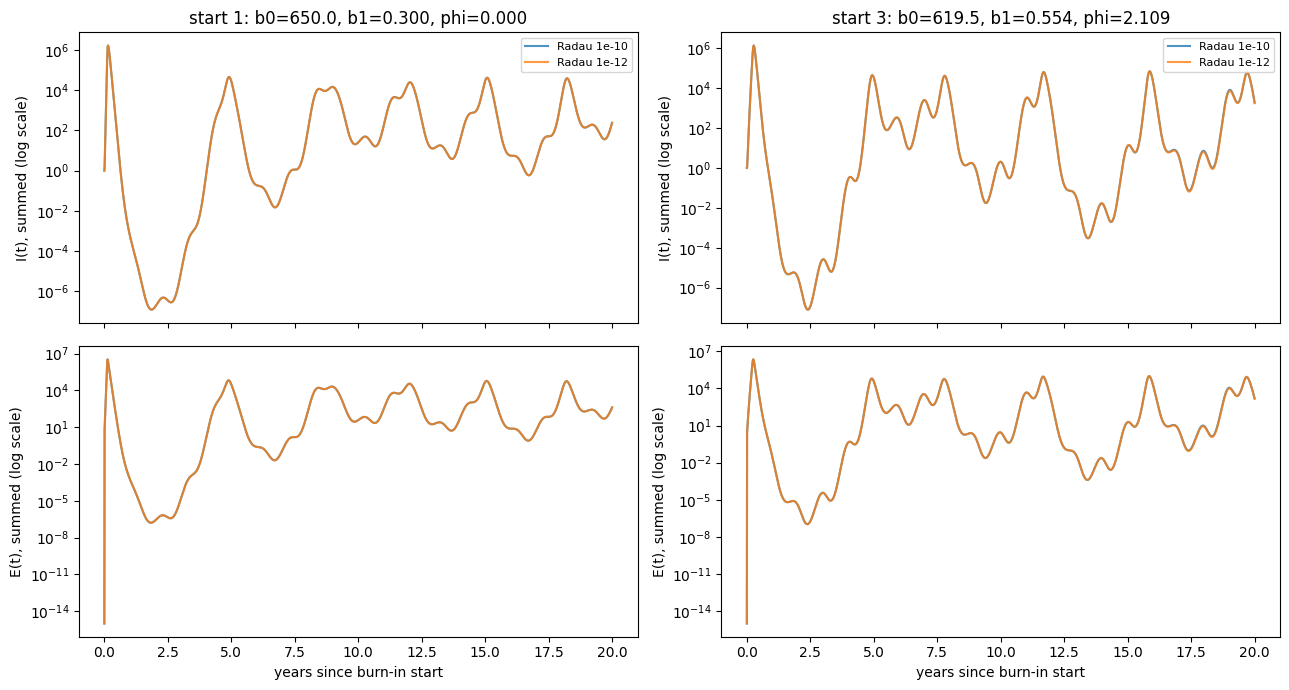

In [13]:
# ---------------------------------------------------------------------------
# Fixed: pass max_rhs_evals through (the bare function default is 50000,
# which start 3 -- and likely start 1 -- can exceed at tight tolerance).
# Also: run trajectories at TWO tolerances -- 1e-10, where Radau/LSODA/BDF
# still broadly agreed in the earlier sweep, and 1e-12, which cell 1
# suggests may be past the meaningful float-precision floor for this
# system. Comparing the two trajectory shapes directly should show whether
# 1e-12 is genuinely resolving something different or just injecting noise.
# ---------------------------------------------------------------------------

from src import model as _model

def burn_in_trajectory(b0, b1, ph, **solve_ivp_kwargs):
    solve_ivp_kwargs.setdefault("max_rhs_evals", 5_000_000)

    burn_in_start_year = fit_start_year - burn_in_years
    burn_in_start_population = historical_population.population_for_year(burn_in_start_year)

    naive_ic = historical_population.initial_conditions_for_population(
        burn_in_start_population,
        seed_infected_per_group=1.0,
        seed_group_index=0,
        cfg=config,
    )

    birth_rate_fn, death_rate_fn = historical_population.build_vital_rate_functions()

    def birth_rate_of_t(t):
        return birth_rate_fn(burn_in_start_year + t)

    def death_rate_of_t(t):
        return death_rate_fn(burn_in_start_year + t)

    burn_in_parameters = {
        "beta_0": float(b0), "beta_1": float(b1), "phi": float(ph),
        "gamma": float(fixed_gamma), "sigma": float(fixed_sigma),
        "maternal_waning_rate": float(fixed_mwr),
        "birth_rate": birth_rate_of_t, "death_rate": death_rate_of_t,
        "vaccination_rates": np.asarray(config.CALIBRATION_FIXED_VACCINATION_RATES, dtype=float),
        "contact_matrix": contact_matrix_array,
    }

    times = np.linspace(0.0, float(burn_in_years), 2000)
    return times, _model.simulate_model(burn_in_parameters, naive_ic, times, **solve_ivp_kwargs)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex="col")
tol_pairs = [("Radau 1e-10", dict(method="Radau", rtol=1e-10, atol=1e-10)),
             ("Radau 1e-12", dict(method="Radau", rtol=1e-12, atol=1e-12))]

for col, start_index in enumerate([0, 2]):  # start 1, start 3
    b0, b1, ph = starts[start_index]

    for label, kwargs in tol_pairs:
        try:
            t, result = burn_in_trajectory(b0, b1, ph, **kwargs)
        except RuntimeError as exc:
            print(f"start {start_index + 1}, {label}: FAILED -- {exc}")
            continue

        I_total = np.asarray(result.I).sum(axis=-1)
        E_total = np.asarray(result.E).sum(axis=-1)

        axes[0, col].semilogy(t, np.abs(I_total) + 1e-15, label=label, alpha=0.8)
        axes[1, col].semilogy(t, np.abs(E_total) + 1e-15, label=label, alpha=0.8)

        print(f"start {start_index + 1}, {label}: I(t) min={I_total.min():.3e}, "
              f"max={I_total.max():.3e}, final={I_total[-1]:.3e}, "
              f"range={np.log10(I_total.max() / max(I_total.min(), 1e-300)):.1f} decades")

    axes[0, col].set_title(f"start {start_index + 1}: b0={b0:.1f}, b1={b1:.3f}, phi={ph:.3f}")
    axes[0, col].set_ylabel("I(t), summed (log scale)")
    axes[0, col].legend(fontsize=8)
    axes[1, col].set_xlabel("years since burn-in start")
    axes[1, col].set_ylabel("E(t), summed (log scale)")

plt.tight_layout()
plt.show()

In [16]:
# ---------------------------------------------------------------------------
# Combined cell:
#  1. Re-run the Radau-only tolerance sweep (1e-9..1e-12) across all 8
#     starts, with a CORRECTED summary that matches these actual configs
#     (the previous summary block still referenced old "BDF" keys and
#     falsely flagged every start as incomplete).
#  2. For start 1 specifically -- which alternated cleanly between two
#     values by tolerance-exponent parity rather than either converging
#     or diverging -- test whether that pattern tracks n_burn_in_points
#     (output-grid aliasing against the trough spacing) rather than
#     solver tolerance itself.
# ---------------------------------------------------------------------------

def _rel_diff(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    denom = np.maximum(np.abs(a), np.abs(b))
    denom = np.where(denom == 0, 1.0, denom)
    return np.max(np.abs(a - b) / denom)

# --- Part 1: Radau-only sweep, all 8 starts ---------------------------------

configs = [
    dict(label="Radau, rtol=atol=1e-9",  method="Radau", rtol=1e-9,  atol=1e-9),
    dict(label="Radau, rtol=atol=1e-10", method="Radau", rtol=1e-10, atol=1e-10),
    dict(label="Radau, rtol=atol=1e-11", method="Radau", rtol=1e-11, atol=1e-11),
    dict(label="Radau, rtol=atol=1e-12", method="Radau", rtol=1e-12, atol=1e-12),
]

all_results = {}

for start_index, (b0, b1, ph) in enumerate(starts):
    print(f"\n=== start {start_index + 1}/{len(starts)}: "
          f"beta_0={b0:.4f}, beta_1={b1:.6f}, phi={ph:.6f} ===")

    per_config = {}
    for cfg in configs:
        cfg = dict(cfg)
        label = cfg.pop("label")
        try:
            ic_c = historical_population.initial_conditions_with_burn_in(
                fit_start_year=fit_start_year, burn_in_years=burn_in_years,
                contact_matrix_array=contact_matrix_array,
                burn_in_beta_0=b0, burn_in_beta_1=b1, burn_in_phi=ph,
                burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
                burn_in_maternal_waning_rate=fixed_mwr,
                n_burn_in_points=2000,
                max_rhs_evals=5_000_000,
                **cfg,
            )
            per_config[label] = ic_c
            print(f"  {label}: I0={ic_c['I0']}")
            print(f"           E0={ic_c['E0']}")
        except RuntimeError as exc:
            per_config[label] = None
            print(f"  {label}: FAILED -- {exc}")

    all_results[start_index] = per_config

print("\n" + "=" * 70)
print("Radau-only convergence summary (max relative diff, I0 & E0)")
print("=" * 70)

tol_labels = [cfg["label"] for cfg in configs]
flagged = []

for start_index, per_config in all_results.items():
    vals = [per_config.get(lbl) for lbl in tol_labels]
    if any(v is None for v in vals):
        print(f"start {start_index + 1}: missing a config -- check log above")
        flagged.append(start_index)
        continue

    diffs = [
        max(_rel_diff(vals[i]["I0"], vals[i + 1]["I0"]), _rel_diff(vals[i]["E0"], vals[i + 1]["E0"]))
        for i in range(len(vals) - 1)
    ]
    # also check first-vs-last directly, since an alternating (non-monotonic)
    # pattern can hide behind small step-to-step diffs if it cycles with
    # period 2 -- catches start-1-style behavior explicitly.
    diff_end_to_end = max(_rel_diff(vals[0]["I0"], vals[-1]["I0"]), _rel_diff(vals[0]["E0"], vals[-1]["E0"]))

    status = "OK" if max(diffs) < 0.02 and diff_end_to_end < 0.02 else "FLAG"
    if status == "FLAG":
        flagged.append(start_index)

    step_str = ", ".join(
        f"{tol_labels[i][-5:]}->{tol_labels[i+1][-5:]}={d:.2%}" for i, d in enumerate(diffs)
    )
    print(f"start {start_index + 1}: {step_str}, 1e-9->1e-12={diff_end_to_end:.2%}  [{status}]")

if flagged:
    print(f"\n{len(flagged)}/{len(starts)} starts flagged: {[i + 1 for i in flagged]}")
else:
    print(f"\nAll {len(starts)} starts converge cleanly with Radau alone.")

# --- Part 2: start 1 -- does the alternating pattern track n_burn_in_points? ---

print("\n" + "=" * 70)
print("Start 1 diagnostic: does output-grid density (n_burn_in_points)")
print("explain the tolerance-parity alternation, at fixed tolerance?")
print("=" * 70)

b0_s1, b1_s1, ph_s1 = starts[0]
grid_sizes = [500, 1000, 2000, 4000, 8000]
fixed_tol = 1e-10  # one of the two values in the alternating pattern

grid_results = {}
for n_pts in grid_sizes:
    ic_c = historical_population.initial_conditions_with_burn_in(
        fit_start_year=fit_start_year, burn_in_years=burn_in_years,
        contact_matrix_array=contact_matrix_array,
        burn_in_beta_0=b0_s1, burn_in_beta_1=b1_s1, burn_in_phi=ph_s1,
        burn_in_gamma=fixed_gamma, burn_in_sigma=fixed_sigma,
        burn_in_maternal_waning_rate=fixed_mwr,
        n_burn_in_points=n_pts,
        max_rhs_evals=5_000_000,
        method="Radau", rtol=fixed_tol, atol=fixed_tol,
    )
    grid_results[n_pts] = ic_c
    print(f"  n_burn_in_points={n_pts:5d}: I0 sum={ic_c['I0'].sum():.4f}, E0 sum={ic_c['E0'].sum():.4f}")

sums = [grid_results[n]["I0"].sum() for n in grid_sizes]
spread = (max(sums) - min(sums)) / max(sums)
print(f"\n  I0-sum spread across grid sizes at fixed tol={fixed_tol:.0e}: {spread:.2%}")
if spread > 0.02:
    print("  -> RESULT DEPENDS ON OUTPUT GRID DENSITY at fixed tolerance.")
    print("     This supports output-grid aliasing against the trough spacing")
    print("     (a sampling artifact on a converged continuous trajectory),")
    print("     not a tolerance-driven numerical error. Fix: choose")
    print("     n_burn_in_points denser than the fastest trough cycle, or")
    print("     report the true endpoint (t=burn_in_years exactly) rather")
    print("     than the nearest output-grid point.")
else:
    print("  -> Result is stable across grid density -- the alternation seen")
    print("     across tolerance exponents is NOT a grid-sampling artifact.")
    print("     Points back toward a genuine solver/tolerance-parity effect")
    print("     or dynamical sensitivity specific to this start.")


=== start 1/8: beta_0=650.0000, beta_1=0.300000, phi=0.000000 ===
  Radau, rtol=atol=1e-9: I0=[48.42253264 54.88409795 44.63653477 32.18359406 22.22438771 29.91795714]
           E0=[83.41110797 93.29441809 75.55789956 54.38187067 37.51988521 49.93112154]
  Radau, rtol=atol=1e-10: I0=[51.81763957 58.74377998 47.8028158  34.49629101 23.84330831 32.10837493]
           E0=[89.28265754 99.88113593 80.93844772 58.30474319 40.26338776 53.60277365]
  Radau, rtol=atol=1e-11: I0=[48.43804902 54.9017332  44.65099631 32.1941534  22.23177821 29.92795036]
           E0=[83.43793743 93.32450799 75.58247    54.3997785  37.53240722 49.94786887]
  Radau, rtol=atol=1e-12: I0=[52.07105543 59.03199458 48.039368   34.66911783 23.96427697 32.27216471]
           E0=[ 89.72106339 100.37314965  81.3405603   58.59799479  40.46845536
  53.87742606]

=== start 2/8: beta_0=758.3482, beta_1=0.070605, phi=6.202651 ===
  Radau, rtol=atol=1e-9: I0=[542.77582995 567.67845666 441.04884353 309.34684094 207.03056158
 3